This first notebook is to create the calibration files necessary for data reduction. It:

1. Trims overscan
2. Creates and subtracts a master bias file (to get rid of the electrical noise in the system)
3. Creates a master dome flat file (to correct for flux differences across the frame)
4. Creates a master arc file (for wavelength calibration so we have a wavelength axis along the x-axis)
5. Checks wavelength calibration (pixel to wavelength polyfit. Should be a straight line with points through the fit). 

In [2]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [4]:
#These are the python packages that are needed for the full code. 
#If you get an error, that means some package must be installed on python
#To install a package like "extinction", open conda prompt and just type in "pip install extinction"
#Let me know if you have any issues with this

from astropy.io import fits
import astropy
import matplotlib.pyplot as plt
import numpy as np
import datetime
import glob
from scipy.optimize import curve_fit
from numpy import loadtxt
from matplotlib.backends.backend_pdf import PdfPages
from astropy import units as u
from astropy.io.fits import Header
import os
import astropy.stats as ap
from astropy.io import fits
from astropy.modeling import models, fitting
from astropy.modeling.models import custom_model
from astropy.modeling import Fittable1DModel, Parameter
import pandas as pd
import matplotlib.pyplot as plt
from scipy import interpolate
import numpy as np
import math
import numpy.polynomial.polynomial as poly
import fnmatch
from matplotlib.colors import PowerNorm
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy import stats

**First Part of code to change**

In the following cell, change all the input variables. 


**Note:** This should be the only cell you need to change things in. At the end of the code, double check that the column fit is working (before the header input). If it is not, you will need to change that part of the code too.

In [6]:
#In this cell, we will be changing the inputs required throughout the rest of the pipeline
path = "/Users/spogs/Documents/TypeIt_Data_Reduction_Pipeline/"#This is the file path to the main reduction
galaxy_name = "J0800+3743_major" #Using our observing logs, this is the galaxy's name that we want to reduce
galaxy_name_2 = "J0800+3743"
galaxy_file_name = galaxy_name #Same as last line (Artifact of a past code that needed 2)
standard_star_name = "HR3454" #Standard star name (Also observed right before/after our galaxy)
date = "2-16" #observation date as a number
date_link = "Feb 16 2020" # observation date
RA = 120.1986 #galaxy's RA value from SPOGs catalog
Dec = 37.7287 #galaxy's Dec value from SPOGs catalog
setting = "A" #Should be an A or B. This refers to the wavelength range observed.
#The observing logs should indicate which
#Using observing logs, this is the file numbers for the bias calibration frames that we took
bias_files = [16, 17, 18, 19,20, 21, 22, 23, 24, 25]
#Using observing logs, this is the file numbers for the dome flat calibration frames that we took
dome_flat_files = [26, 27, 28, 29, 30]
#Using observing logs, this is the file numbers for the arc calibration frames that we took
arc_files = [11, 12, 13, 14, 15]
#Using observing logs, this is the file numbers for the galaxy files
galaxy_files = [37,38,39,40]
number_of_galaxy_files = len(galaxy_files)
galaxy_exposure_times = [900, 900, 900,900]
#Using observing logs, this is the file numbers for the star files
star_files = [35,36]
number_of_star_files = len(star_files)
star_exposure_times = [1, 1]
literature_standard_star_values = "HR3454.txt"
target_row = 141
target_row_script = "141"

In [7]:
#Create Log file that includes all the settings above so we can review them at a later point of time.

with open(path + "Observations/" + date_link +'/LOGFILE/' + galaxy_name + '_' + 'LOGFILE.txt','w') as f:
    f.write('Path:')
    f.write(path) 
    f.write("\n")
    f.write('Galaxy Name:')
    f.write(galaxy_name)
    f.write("\n")
    f.write('Galaxy Name 2:')
    f.write(galaxy_name_2)
    f.write("\n")
    f.write('G File Name:')
    f.write(galaxy_file_name) 
    f.write("\n")
    f.write('Standard Star Name:')
    f.write(standard_star_name) 
    f.write("\n")
    f.write('Observation Date:')
    f.write(date) 
    f.write("\n")
    f.write('Observation Date Link:')
    f.write(date_link) 
    f.write("\n")
    f.write('Galaxy RA:')
    f.write(str(RA)) 
    f.write("\n")
    f.write('Galaxy Dec:')
    f.write(str(Dec)) 
    f.write("\n")
    f.write('Galaxy Redshift Setting:')
    f.write(setting) 
    f.write("\n")  
    f.write('Bias File Numbers Used:')
    f.write("\n")
    f.write(str(bias_files))  
    f.write("\n")
    f.write('Dome Flat File Numbers Used:')
    f.write("\n")
    f.write(str(dome_flat_files)) 
    f.write("\n")
    f.write('Arc Frame File Numbers Used:')
    f.write("\n")
    f.write(str(arc_files)) 
    f.write("\n")
    f.write('Number of Galaxy frames median combined:')
    f.write("\n")
    f.write(str(number_of_galaxy_files)) 
    f.write("\n") 
    f.write('Galaxy Frame File Numbers:')
    f.write("\n")
    f.write(str(galaxy_files)) 
    f.write("\n")    
    f.write('Galaxy Frame Exposure Time:')
    f.write("\n")
    f.write(str(galaxy_exposure_times)) 
    f.write("\n")
    f.write('Number of Standard Star frames to be median combined:')
    f.write("\n")
    f.write(str(number_of_star_files)) 
    f.write("\n")
    f.write('Standard Star Frame File Numbers:')
    f.write("\n")
    f.write(str(star_files)) 
    f.write("\n")
    f.write('Standard Star Frame Exposure Time:')
    f.write("\n")
    f.write(str(star_exposure_times)) 
    f.write("\n")
    f.write('Standard Star Literature Value Txt File Used:')
    f.write(literature_standard_star_values) 
    f.write("\n")
    f.write('Target Row:')
    f.write(str(target_row))
    f.write("\n")
    f.write(target_row_script) 
    f.write("\n")

In [8]:
#Loading in raw files for overscan subtraction 
files = sorted(glob.glob(path + "Observations/" + date_link +"/*.fits"))
frame = fits.open(files[0])
frame.info()

Filename: /Users/spogs/Documents/TypeIt_Data_Reduction_Pipeline/Observations/Feb 16 2020/20200216.0001.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     194   (2148, 516)   int16 (rescales to uint16)   


In [9]:
print(int(len(files)))

105


In [10]:
#Subtracting the overscan from each file
#This cell will potentially output "Keyword 'OBJECT' not found.", ignore it
data = frame[0].data
data= data[6:511,55:2095]
print(int(len(files)))
name = frame[0].header["Object"].replace(" ","_")
test = files[0:int(len(files))] 
count = 1
for i in test:
    frame = fits.open(i,memmap=False)
    header=frame[0].header
    name = frame[0].header["Object"].replace(" ","_") 
    data = frame[0].data
    data= data[12:494,54:2096]
    hdu_data = fits.PrimaryHDU(data)
    hdu_data.header= header
    if len(name) == 0:
        hdu_data.writeto(path + "Observations/" + date_link + "/Trimmed Data/" + "Unnamed_"  + "File"+ "_" + str(count) + ".fits", overwrite = True)
    else:
        hdu_data.writeto(path + "Observations/" + date_link + "/Trimmed Data/" + str(name)+ "_"  + "File"+ "_" + str(count) + ".fits", overwrite = True)
    count += 1

105


In [15]:
#Load in all of the bias files using input cell above. Nothing needs to be changed here.

#For loop is example of loading in any number of files
stacked_biases = []
myfile = open(path + "Observations/" + date_link +'/LOGFILE/Bias_Files_' + 'LOGFILE.txt', 'w')
for i in range(len(bias_files)):
    #Finds any file with "File_[insert number here]", which is the syntax I wrote all file numbers to be
    finding = fnmatch.filter(os.listdir(path + "Observations/" + date_link + "/Trimmed Data/."), '*' + 'File_' + str(bias_files[int(i)]) + '.fits')
    print(finding)
    #Opens file itself finally. . . 
    frame = fits.open(path + "Observations/" + date_link + "/Trimmed Data/" + finding[0]) 
    data = frame[0].data
    stacked_biases.append(data)
    myfile.write("%s\n" %finding)
myfile.close()
bias_median = np.median(stacked_biases,axis=0)

#Error for Median Master Bias is the standard deviation of the values at each pixel location
bias_error = np.std(stacked_biases,axis=0)/np.sqrt(len(stacked_biases))

x = np.linspace(0,2042,num=2042)

# Create figure and gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 1, height_ratios = [1,3], hspace = 0.000000000001)  # 4:1 width ratio

# Main plot
ax_main = fig.add_subplot(gs[1])

# Side histogram (right)
#ax_hist = fig.add_subplot(gs[1,1], sharey=ax_main)  # Share y-axis for alignment

ax_top = fig.add_subplot(gs[0], sharex=ax_main)

ax_top.plot(x,bias_median[250:251, :][0], label = "Median-Combined Bias Slice")
ax_top.set_ylabel("Count Values")
ax_top.set_ylim(2360,2380)

ax_top.xaxis.tick_top()
#ax_top.tick_params(axis='x', labeltop=False)
ax_top.xaxis.set_label_position("top")
plt.legend()
plt.tight_layout()
fig.subplots_adjust(hspace=0.001, top=0.50, bottom=0.00002)



#Plotting master bias frame. Double check in ds9 to be sure it's a bias frame (looks noisy) 
#For this plot, also used vmin=0, but that creates a white plot that is meaningless. 
#plt.figure(figsize=(15,15))
ax_main.imshow(bias_median,origin="lower",cmap="gray")
#plt.title("Median Bias")
ax_main.set_xlabel("Column Number")
ax_main.set_ylabel("Row Number")


if not os.path.exists(path + "Working Files/Image Sets/"):
    os.makedirs(path + "Working Files/Image Sets/")
plt.savefig(path + "Working Files/Image Sets/Master_Bias_Combined.png", bbox_inches='tight')
plt.savefig(path + "Working Files/Image Sets/Master_Bias_Combined.pdf", bbox_inches='tight')
plt.close()





#Plotting master bias error frame.        
plt.figure(figsize=(15,15))
plt.imshow(bias_error,origin="lower",cmap="gray",vmax = 2) 
plt.title("Median Bias Error")
plt.xlabel("Column Number")
plt.ylabel("Row Number")
if not os.path.exists(path + "Working Files/Image Sets/"):
    os.makedirs(path + "Working Files/Image Sets/")
plt.savefig(path + "Working Files/Image Sets/Master_Bias_Error.png", bbox_inches='tight')
plt.savefig(path + "Working Files/Image Sets/Master_Bias_Error.pdf", bbox_inches='tight')
plt.close()

#Plotting the target row of master bias error frame and saving it (from cell input above)
plt.figure(figsize=(15,5))
x_values = np.linspace(0,2041,2042)
row_slice = np.resize(bias_error[target_row-1: target_row,:], 2042)
plt.plot(row_slice)
plt.title("Row "+target_row_script+" Median Bias Error")
plt.xlabel("Column Number")
plt.ylabel("Stand. Dev.")
if not os.path.exists(path + "Working Files/Error Propagation/Master Bias/"):
    os.makedirs(path + "Working Files/Error Propagation/Master Bias/")
plt.savefig(path + "Working Files/Error Propagation/Master Bias/Bias Slice " + galaxy_name + ".jpg",bbox_inches='tight')
plt.close()

#Writing data to a new fits file
#frame = fits.open(trimmedfiles[0])
hdu_data = fits.PrimaryHDU(bias_median)
hdu_error = fits.ImageHDU(bias_error)
median_bias = fits.HDUList([hdu_data,hdu_error])

#Example code below to create a pathway/folder and then save file into that said path
if os.path.exists(path + "Observations/" + date_link + "/Trimmed Data/Median_Master_bias.fits"):
    os.remove(path + "Observations/" + date_link + "/Trimmed Data/Median_Master_bias.fits")
    
median_bias.writeto(path + "Observations/" + date_link + "/Trimmed Data/Median_Master_bias.fits",overwrite=True)



['Unnamed_File_16.fits']
['Unnamed_File_17.fits']
['Unnamed_File_18.fits']
['Unnamed_File_19.fits']
['Unnamed_File_20.fits']
['Unnamed_File_21.fits']
['Unnamed_File_22.fits']
['Unnamed_File_23.fits']
['Unnamed_File_24.fits']
['Unnamed_File_25.fits']


/var/folders/6r/zhs4r_394xjgjvrj31r7mpdh0000gn/T/ipykernel_13794/1138628372.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


In [19]:
#Load in all overscan subtracted files, then subtract off master bias frame.

#First, load in median master bias
median_master_bias = fits.open(path + "Observations/" + date_link + "/Trimmed Data/Median_Master_bias.fits",memmap = False)
median_bias = median_master_bias[0].data
blank_bias = np.zeros_like(median_master_bias)

#Next, load in all fits files 
trimmedfiles = sorted(glob.glob(path + "Observations/" + date_link + "/Trimmed Data/*.fits"),key=os.path.getmtime)
test = trimmedfiles[0:int(len(files))] 
count = 1

#Subtracting off the master median bias values per pixel location
for item in test:
    ovsub_temp = fits.open(item,memmap = False)
    name = ovsub_temp[0].header["Object"].replace(" ","_")
    indiv_ovsub = ovsub_temp[0].data
    indiv_ovsub = indiv_ovsub.astype(float)
    indiv_ovsub = (indiv_ovsub - median_bias)
    hdu_data = fits.PrimaryHDU(indiv_ovsub)
    
    if len(name) == 0:
        if not os.path.exists(path + "Observations/" + date_link + "/Trimmed Data/Bias Subtracted/"):
            os.makedirs(path + "Observations/" + date_link + "/Trimmed Data/Bias Subtracted/")
        hdu_data.writeto(path + "Observations/" + date_link + "/Trimmed Data/Bias Subtracted/" + "Unnamed_"  + "File"+ "_" + str(count) + ".fits", overwrite = True)
    else:
        if not os.path.exists(path + "Observations/" + date_link + "/Trimmed Data/Bias Subtracted/"):
            os.makedirs(path + "Observations/" + date_link + "/Trimmed Data/Bias Subtracted/")
        hdu_data.writeto(path + "Observations/" + date_link + "/Trimmed Data/Bias Subtracted/" + str(name)+ "_"  + "File"+ "_" + str(count) + ".fits", overwrite = True)
    count += 1


In [21]:
#bias_subtracted_files = sorted(glob.glob(path + "Observations/" + date_link + "/Trimmed Data/Bias Subtracted/*.fits"),key=os.path.getmtime)

In [27]:
#Function for defining error in dome flat individual frames, galaxy frames, and standard star frames

def ErrorExtension(file_number,FrameName):
    #Open the file and extract the data into an ndarray
    #bias_subtracted_files = sorted(glob.glob(path + "Observations/" + date_link + "/Trimmed Data/Bias Subtracted/*.fits"),key=os.path.getmtime)
    
    
    finding2 = fnmatch.filter(os.listdir(path + "Observations/" + date_link + "/Trimmed Data/Bias Subtracted/."), '*' + 'File_' + str(file_number) + '.fits')
    print(finding2)
    
    bias_subtracted = fits.open(path + "Observations/" + date_link + "/Trimmed Data/Bias Subtracted/" + finding2[0])
    arraydata = bias_subtracted[0].data
    
    
    #Create error frame, same shape as data array but is empty 
    Error = np.zeros_like(arraydata)
    FrameError = 0

    
    G = 1.52 #Gain Value
    array = np.array(arraydata)
    float_array = array.astype(np.float32) #converting array into float values
    
    #We define the frame error of Dome/galaxy/star file as electron counts / gain
    xf=float_array/G #converting counts into photon numbers
    FrameError = xf+(bias_error)**2 + (4.9/(1.52**2))**2#Make sure the creation of the master bias step has been done
    FrameError = np.sqrt(FrameError)
    
    #Plotting the 281st row of master bias error frame and saving it
    plt.figure(figsize=(15,5))
    rowz_slice = np.resize(FrameError[target_row-1:target_row,:], 2042)
    plt.plot(rowz_slice)
    plt.title("Row "+ target_row_script +" Error " + FrameName + ";  " + date)
    plt.xlabel("Column Number")
    plt.ylabel("Error [" + FrameName + "] " + galaxy_name + " (st. dev.)")
    #plt.savefig(path + "Working Files/Error Propagation/Dome Science Raw Error/" + FrameName + date + " " + galaxy_name + ".jpg",bbox_inches='tight')
    plt.close()
    
    
    #adding the calculated error onto the domeflat frame as a seperate extension
    Frame= fits.PrimaryHDU(arraydata)
    EFrame = fits.ImageHDU(FrameError)

    Frame_Extended = fits.HDUList([Frame,EFrame])
    if not os.path.exists(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/"):
            os.makedirs(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/")
    Frame_Extended.writeto(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" +FrameName + ".fits",overwrite=True)

    #Error_Added_File = sorted(glob.glob(path + "Data Reduction Error Propagation/Output Data Cubes/" +FrameName + ".fits"))
    frame = fits.open(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" +FrameName + ".fits")
    frame.info()
    return frame.close()
    

In [29]:
#Naming dome flat files and then using said name and the error extension function above to create 
#dome flat files that have errors
for i in range(len(dome_flat_files)):
    dome = "Dome_Flat_" + str(i+1)
    print(dome)
    ErrorExtension(dome_flat_files[i],dome)

Dome_Flat_1
['Unnamed_File_26.fits']
Filename: /Users/spogs/Documents/TypeIt_Data_Reduction_Pipeline/Observations/Feb 16 2020/Trimmed Data/Bias Subtracted/A/Dome_Flat_1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (2042, 482)   float64   
  1                1 ImageHDU         7   (2042, 482)   float64   
Dome_Flat_2
['Unnamed_File_27.fits']
Filename: /Users/spogs/Documents/TypeIt_Data_Reduction_Pipeline/Observations/Feb 16 2020/Trimmed Data/Bias Subtracted/A/Dome_Flat_2.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (2042, 482)   float64   
  1                1 ImageHDU         7   (2042, 482)   float64   
Dome_Flat_3
['Unnamed_File_28.fits']
Filename: /Users/spogs/Documents/TypeIt_Data_Reduction_Pipeline/Observations/Feb 16 2020/Trimmed Data/Bias Subtracted/A/Dome_Flat_3.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 Pri

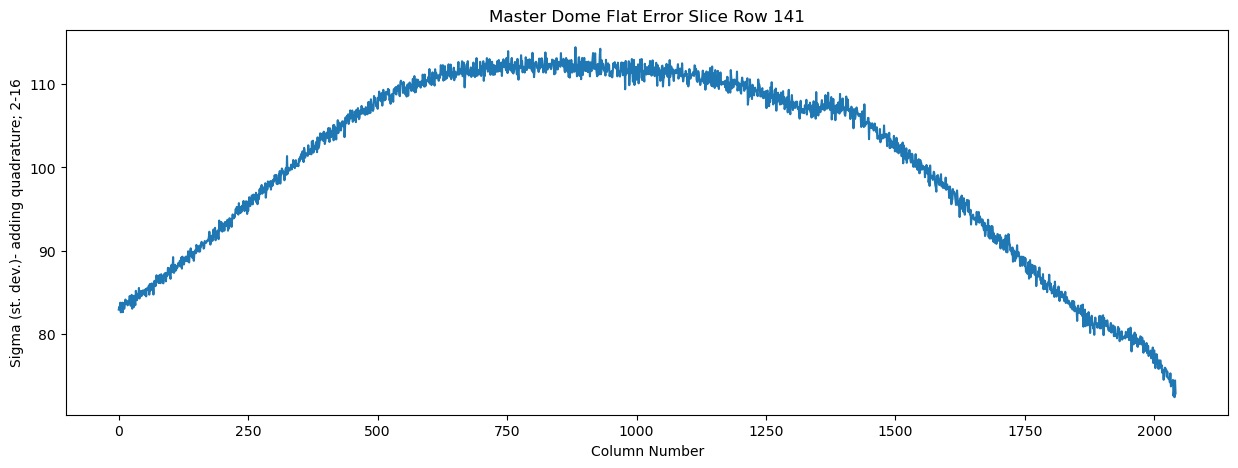

In [31]:
#Master Dome flat creation

#Same loading in strategy from bias frames. Can load in any number of bias frames.
#This is unique as it also loads in the error extensions that must be propagated into the master dome 
#file
stacked_domes = []
stacked_dome_errors = []
myfile2 = open(path + "Observations/" + date_link +'/LOGFILE/Flatfielding_Files_' + 'LOGFILE.txt', 'w')
for i in range(len(dome_flat_files)):
    dome_frame = fits.open(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/Dome_Flat_" +str(i+1) + ".fits")
    dome_data = dome_frame[0].data
    error_dome = dome_frame[1].data**2
    #print(error_dome)
    stacked_domes.append(dome_data)
    stacked_dome_errors.append(error_dome)
    myfile2.write("%s\n" % path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/Dome_Flat_" +str(i+1) + ".fits")
myfile2.close()
master_flat = np.nanmedian(stacked_domes,axis=0)

median_std = np.nansum(stacked_dome_errors,axis=0)
median_std = median_std/len(dome_flat_files)
median_std = (np.pi/2)*median_std
median_std = np.sqrt(median_std)

#Plot of the error slice of dome flat. 
#For setting A, should be a pretty perfect quadratic pointing downwards with a peak ~120 
#For setting B, this should be shifted to the right with a longer tail at low column numbers
plt.figure(figsize=(15,5))
row_d_slice = np.resize(median_std[target_row-1:target_row,:], 2042)
plt.plot(row_d_slice)
plt.title("Master Dome Flat Error Slice Row "+ target_row_script)
plt.xlabel("Column Number")
plt.ylabel("Sigma (st. dev.)- adding quadrature; " + date)
if not os.path.exists(path + "Working Files/Error Propagation/Master Dome/"):
    os.makedirs(path + "Working Files/Error Propagation/Master Dome/")
plt.savefig(path + "Working Files/Error Propagation/Master Dome/Master Dome Flat " + date + ".jpg",bbox_inches='tight')



In [33]:
#Master dome flat creation continued. . . .

#Take the central 50 rows around the galaxy spectra, median combine them, and use that for the polyfit
y = master_flat[215:265, :]
temp_y = []

for column in range((master_flat.shape[1])):
    y = master_flat[215:265, column]
    temp_y.append(np.median(y))

#Plot to compare the polyfit to our dome flat data
#As a dome flat file, the peak should be ~16,000 counts. More is fine.
#Counts under 10,000 are suspect 
x = np.linspace(0,2042,num=2042)
p = np.poly1d(np.polyfit(x, temp_y, 8))



# Create figure and gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 1, height_ratios = [1,3], hspace = 0.000000000001)  # 4:1 width ratio

# Main plot
ax_main = fig.add_subplot(gs[1])

# Side histogram (right)
#ax_hist = fig.add_subplot(gs[1,1], sharey=ax_main)  # Share y-axis for alignment

ax_top = fig.add_subplot(gs[0], sharex=ax_main)

ax_top.plot(x,temp_y, label = "Dome Data")


ax_top.plot(x,p(x), label = "Polyfit")
#plt.title("Polynomial Fit to Median Combined Dome Flat Rows")
#ax_top.set_xlabel("Column Number")
ax_top.set_ylabel("Count Values")


ax_top.xaxis.tick_top()
#ax_top.tick_params(axis='x', labeltop=False)
ax_top.xaxis.set_label_position("top")
plt.legend()
plt.tight_layout()
fig.subplots_adjust(hspace=0.001, top=0.50, bottom=0.00002)
#plt.savefig(path + "Working Files/Dome Flat Fit/Master Dome Flat " + date + ".jpg",bbox_inches='tight')

#To get rid of shape of the lamp, we divide dome flat by the polynomial fit we just created
flat_stack = np.zeros(shape=(482,2042))
err_flat_stack = np.zeros(shape=(482,2042))
for row in range((master_flat.shape[0])):
    flat_stack[row, :] = master_flat[row, :]/p(x)
    err_flat_stack[row, :]  = median_std[row, :]/p(x)
    
#Error propagation steps below
err_mean_flat_stack = np.std(flat_stack)/np.sqrt(flat_stack.shape[0]*flat_stack.shape[1]) #2042 x 482 shape (number of pixels)
flat_norm = flat_stack / np.mean(flat_stack) 
std = abs(flat_norm)*np.sqrt((err_flat_stack/flat_stack)**2+(err_mean_flat_stack/np.mean(flat_stack))**2)

#Plot to see master dome flat image

#plt.figure(figsize=(15,15))
ax_main.imshow(master_flat,origin="lower",cmap="gray",vmin=0)
ax_main.set_xlabel("Column Number")
ax_main.set_ylabel("Row Number")

#ax_main.title("Master Dome Flat")
if not os.path.exists(path + "Working Files/Image Sets/"):
    os.makedirs(path + "Working Files/Image Sets/")
plt.savefig(path + "Working Files/Image Sets/Master_Dome_Combined.png", bbox_inches='tight')
plt.savefig(path + "Working Files/Image Sets/Master_Dome_Combined.pdf", bbox_inches='tight')
plt.close()

#Plot to see master dome flat ERROR image
plt.figure(figsize=(15,15))
plt.imshow(std,origin="lower",cmap="gray",vmin=0)
plt.title("Master Dome Flat Error")
if not os.path.exists(path + "Working Files/Image Sets/"):
    os.makedirs(path + "Working Files/Image Sets/")
plt.savefig(path + "Working Files/Image Sets/Master_Dome_Error.png", bbox_inches='tight')
plt.savefig(path + "Working Files/Image Sets/Master_Dome_Error.pdf", bbox_inches='tight')
plt.close()

#saving master dome flat as a fits file, either in the setting A or setting B directory
Dome_Frame= fits.PrimaryHDU(flat_norm)
Error_Dome_Frame = fits.ImageHDU(std)

Master_Flat_Frame = fits.HDUList([Dome_Frame,Error_Dome_Frame])
Master_Flat_Frame.writeto(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + "Master_Dome_Flat_" + setting + ".fits",overwrite=True)


/var/folders/6r/zhs4r_394xjgjvrj31r7mpdh0000gn/T/ipykernel_13794/2974141665.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


In [35]:
#Loading in arc frames similar to dome flat and bias files when median combining
stacked_arcs = []
myfile3 = open(path + "Observations/" + date_link +'/LOGFILE/Arc_Frames_Files_' + 'LOGFILE.txt', 'w')
files = sorted(glob.glob(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/*.fits"),key=os.path.getmtime)

for i in range(len(arc_files)):
    finding3 = fnmatch.filter(os.listdir(path + "Observations/" + date_link + "/Trimmed Data/Bias Subtracted/."), '*' + 'File_' + str(arc_files[i]) + '.fits')
    print(finding3)
    arc_frame = fits.open(path + "Observations/" + date_link + "/Trimmed Data/Bias Subtracted/" + finding3[0])
    arc_data = arc_frame[0].data
    #print(error_dome)
    stacked_arcs.append(arc_data)
    print(arc_files[int(i)])
    #Writes out the arc file numbers used
    #Note: in python this prints as the same file as from the input cell at the start of the notebook
    #       HOWEVER, in the logfile it prints out the correct numbered file (i+1)
    myfile3.write("%s\n" % files[arc_files[int(i)]])
myfile3.close()
master_arc = np.median(stacked_arcs,axis=0)

#Quick plot to see if the arc frame looks right
#Should have some emission lines running from the top of the frame to the bottom at specific wavelengths
plt.figure(figsize=(15,15))
plt.imshow(master_arc, vmin = 0, vmax = 3000)
plt.xlabel("Column Number")
plt.ylabel("Row Number")
if not os.path.exists(path + "Working Files/Image Sets/"):
    os.makedirs(path + "Working Files/Image Sets/")
plt.savefig(path + "Working Files/Image Sets/Master_Arc.pdf", bbox_inches='tight')
plt.savefig(path + "Working Files/Image Sets/Master_Arc.pdf", bbox_inches='tight')
plt.close()

hdu_arc = fits.PrimaryHDU(master_arc)
hdu_arc.writeto(path + "Observations/"+ date_link +"/Trimmed Data/Bias Subtracted/" + setting +"/" + "Master_Arc_"+ setting + ".fits",overwrite=True)

['Unnamed_File_11.fits']
11
['Unnamed_File_12.fits']
12
['Unnamed_File_13.fits']
13
['Unnamed_File_14.fits']
14
['Unnamed_File_15.fits']
15


Wavelength Calibration step:

Using the master arc file created in the previous cell, we create "wav-DATE-2.txt" tables that list at each pixel column emission what the associated emission is. 

Initially, this is just a guess that we write into wav-DATE.txt using the DeVeny manual's emission plots. Afterwards, I use the "Wavelength Pixel-Angstrom..." code to fit Gauassians and get a more precise pixel number for each emission line. This gives us the "wav-DATE-2.txt" file.

If there is a missing "wav-DATE-2.txt" file, just let me know and I'll create it.





1D polyfit function coefficients: [-1.33812451e+00  7.27014291e+03]
[7270.14291499 7268.80479048 7267.46666596 ... 4541.70703177 4540.36890726
 4539.03078274]


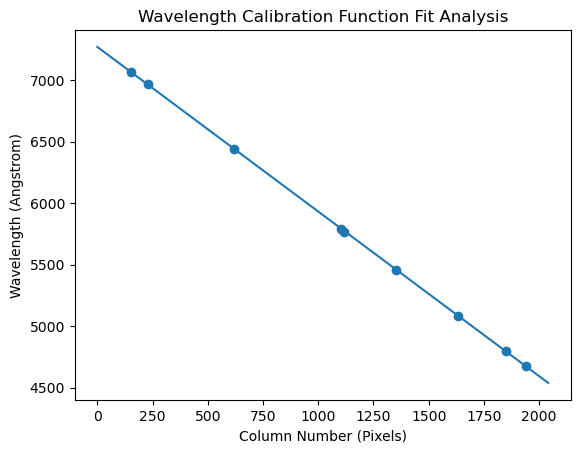

Starting Wavelength: 4539.03078274413
R-squared value: 0.9999845834764535


In [38]:
#Plotting Pixel column to wavelength column
pixel = np.loadtxt(path + 'Observations/Wav_'+ date +'-2_' + setting + '.txt', comments="#",delimiter="	")
x = pixel[:,1]
y = pixel[:,0]
p = np.polyfit(x, y, 1)
print('1D polyfit function coefficients:',p)


plt.show()
xaxis= np.linspace(0,2041,num=2042)
yaxis= np.polyval([p[0],p[1]],xaxis)
print(yaxis)
fig = plt.figure()

plt.scatter(x,y)

plt.plot(xaxis,yaxis)
plt.xlabel('Column Number (Pixels)',color='black')
plt.ylabel('Wavelength (Angstrom)',color='black')
plt.title("Wavelength Calibration Function Fit Analysis",color='black')
f=plt.show()
print('Starting Wavelength:' , np.polyval([p[0],p[1]],2041))
if not os.path.exists(path + "Working Files/Wavelength Fits/"):
    os.makedirs(path + "Working Files/Wavelength Fits/")
fig.savefig(path + "Working Files/Wavelength Fits/Wavelength Fit " + date + ".pdf")

#R squared calculation to see how close our fit is to the emission points. Should be close to 1:
diff = y-y.mean()
squarediff= diff**2
SST= squarediff.sum()
difff= np.polyval([p[0],p[1]],x)-y.mean()
squaredihat=difff**2
SSE=squaredihat.sum()

Rsquared=SSE/SST
print('R-squared value:',Rsquared)

